# Детекция меланомы | Часть 2: Поиск гиперпараметров и обучение ResNet-50

| | |
|---|---|
| **Датасет** | ISIC 2020 (33 126 изображений, менее 2% меланом) |
| **Задача** | Бинарная классификация: меланома / доброкачественное |
| **Архитектура** | ResNet-50 pretrained ImageNet, full fine-tuning |
| **Главная метрика** | AUC-PR (Average Precision) |
| **Вспомогательные** | F1, Recall, Precision, Specificity, Balanced Accuracy |

---

## Структура ноутбука

Поиск лучших гиперпараметров ведётся автоматически через Optuna, затем лучшие конфигурации дообучаются на большем числе эпох.

| Блок | Что делается | Эпох |
|---|---|---|
| **1. Optuna** | Автоматический поиск гиперпараметров: оптимизатор, планировщик, lr, weight decay, dropout, label smoothing | 15 × 15 trials |
| **2. Топ-3** | Три лучшие конфигурации обучаются полноценно, сохраняются веса и метрики | 30 |
| **3. Финал** | Лучшая модель дообучается с early stopping (patience=7) | 50 |

## 1. Конфигурация и импорты

In [2]:
import os
import json
import random
import shutil
import time
import copy

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
)

import optuna
from optuna.pruners import MedianPruner

from torch.cuda.amp import autocast, GradScaler

import IPython.display as ipd

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
# Пути к данным
IMAGE_DIR = "/kaggle/input/datasets/cdeotte/jpeg-melanoma-256x256/train"
TRAIN_CSV  = '/kaggle/input/datasets/dashkanikitina/splitsss/split_train.csv'
VAL_CSV    = '/kaggle/input/datasets/dashkanikitina/splitsss/split_val.csv'
TEST_CSV   = '/kaggle/input/datasets/dashkanikitina/splitsss/split_test.csv'
OUTPUT_DIR = '/kaggle/working'

# DataLoader
BATCH_SIZE  = 32
NUM_WORKERS = 2

In [4]:
# Optuna: база данных для сохранения trials между сессиями
STUDY_DB_PATH = '/kaggle/working/optuna_resnet.db'
STUDY_NAME    = 'resnet50_stage1'

PREV_DB_PATH  = None

# Блок 1: Optuna
N_TRIALS_TOTAL    = 15
OPTUNA_EPOCHS     = 15
# Останавливаю за 1 час до конца сессии Kaggle
TIME_BUDGET_HOURS = 11.0

# Блок 2: топ-3 на полные 30 эпох
NUM_EPOCHS_BLOCK2 = 30
TOP_K             = 3

# Блок 3: дообучение лучшей модели
NUM_EPOCHS_BLOCK3       = 20  # ещё 20 эпох поверх блока 2 (вместе 50)
EARLY_STOPPING_PATIENCE = 7

In [5]:
# Воспроизводимость: seed=42 везде
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)

In [6]:
scaler = GradScaler()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


## 2. Загрузка данных

In [7]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_name"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")  # защита от RGBA/grayscale
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row["target"], dtype=torch.float32)  # float32 для BCEWithLogitsLoss
        return image, label

In [8]:
# Статистики нормализации ImageNet - модель обучена на этих значениях, поэтому входные данные нужно привести к тому же масштабу
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [9]:
# Для обучения аугментация из первой части - базовая геометрическая
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),    
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Для валидации и теста нет аугментации
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [10]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

In [11]:
train_dataset = MelanomaDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset   = MelanomaDataset(val_df,   IMAGE_DIR, transform=val_transform)
test_dataset  = MelanomaDataset(test_df,  IMAGE_DIR, transform=val_transform)

In [12]:
# Balanced batch
n_class0 = int((train_df['target'] == 0).sum())
n_class1 = int((train_df['target'] == 1).sum())
weight_class0  = 1.0 / n_class0
weight_class1  = 1.0 / n_class1
sample_weights = train_df['target'].map({0: weight_class0, 1: weight_class1}).values

sampler = WeightedRandomSampler(
    weights     = torch.FloatTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,  # с возвратом
)

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = False,
)

print('\nDataLoader созданы:')
print('  Батчей в train:', len(train_loader))
print('  Батчей в val:  ', len(val_loader))
print('  Батчей в test: ', len(test_loader))


DataLoader созданы:
  Батчей в train: 777
  Батчей в val:   130
  Батчей в test:  130


## 3. Вспомогательные функции

In [14]:
class LabelSmoothingBCELoss(nn.Module):
    """
    BCEWithLogitsLoss с label smoothing (сглаживание меток).
    Стандартный BCE учит модель быть абсолютно уверенной, что ведёт к переобучению. Label smoothing 'размывает' жёсткие метки {0, 1}.
    В медицинских задачах метки могут быть зашумлены (спорные случаи на границе), поэтому небольшое сглаживание часто улучшает обобщение на новых данных.
    """
    def __init__(self, label_smoothing=0.0):
        super().__init__()
        self.ls  = label_smoothing
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # Сдвигаю метки от краёв шкалы [0,1] ближе к центру
        soft_targets = targets * (1.0 - self.ls) + 0.5 * self.ls
        return self.bce(logits, soft_targets)

In [15]:
def make_resnet50(dropout=0.0):
    """
    Создаёт ResNet-50 с предобучением ImageNet, заменяет последний fc-слой.

    Использую предобученные веса, так как первые слои ResNet обучены находить края, текстуры, формы - универсальные
    признаки, полезные для любых изображений. Fine-tuning переиспользует их, что быстрее и лучше, чем обучение с нуля при ограниченном датасете.

    Dropout перед fc-слоем - случайно отключает нейроны во время обучения, не давая модели полагаться на конкретные признаки - переобучаться.
    """
    try:
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    except AttributeError:
        model = models.resnet50(pretrained=True)

    in_features = model.fc.in_features
    if dropout > 0.0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 1),
        )
    else:
        model.fc = nn.Linear(in_features, 1)
    return model

In [16]:
def compute_metrics(model, loader, criterion=None, threshold=None):
    """
    Прогоняет модель через весь DataLoader, считает все метрики качества.

    threshold=None  -> ищет лучший порог по F1 на переданных данных (для val).
    threshold=float -> применяет фиксированный порог без поиска (для test).
    """
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0.0
    n_batches  = 0 

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images).squeeze(1)
            if criterion is not None:
                total_loss += criterion(logits, labels).item()
                n_batches  += 1
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss = total_loss / n_batches if criterion is not None else None

    # Защита от вырожденного случая (все метки одного класса - бывает в начале обучения)
    if len(np.unique(all_labels)) < 2:
        auc_pr = 0.0
    else:
        # AUC-PR не зависит от порога - суммирует качество по всем возможным порогам
        auc_pr = float(average_precision_score(all_labels, all_probs))

    # Поиск порога, максимизирующего F1 - перебираю все 99 вариантов
    if threshold is None:
        best_f1  = -1.0
        best_thr = 0.5
        for thr in np.arange(0.01, 1.00, 0.01):
            preds_thr = (all_probs >= thr).astype(int)
            f1_thr    = f1_score(all_labels, preds_thr, zero_division=0.0)
            if f1_thr > best_f1:
                best_f1  = f1_thr
                best_thr = float(thr)
        threshold = best_thr

    preds = (all_probs >= threshold).astype(int)

    f1      = float(f1_score(all_labels, preds, zero_division=0.0))
    recall  = float(recall_score(all_labels, preds, zero_division=0.0))
    prec    = float(precision_score(all_labels, preds, zero_division=0.0))
    bal_acc = float(balanced_accuracy_score(all_labels, preds))

    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    return {
        'loss':              avg_loss,
        'auc_pr':            auc_pr,
        'f1':                f1,
        'recall':            recall,
        'precision':         prec,
        'specificity':       specificity,
        'balanced_accuracy': bal_acc,
        'threshold':         threshold,
    }

In [17]:
def make_optimizer(params, model):
    """
    Создаёт оптимизатор по словарю params (от Optuna или сохранённому конфигу).

    Adam - стандарт; адаптивный lr для каждого параметра, хорошо работает 'из коробки'.
    AdamW - как Adam, но weight decay применяется правильно (не через lr, а отдельно). Обычно лучше Adam при fine-tuning предобученных моделей.
    SGD+momentum - классика; может лучше обобщать, но требует аккуратной настройки lr.
    """
    name = params['optimizer']
    lr   = params['lr']
    wd   = params['weight_decay']
    if name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif name == 'AdamW':
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    else:  # SGD
        return optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None):
    """
    Обучает модель одну эпоху. Возвращает средний loss по батчам.

    OneCycleLR делает scheduler.step() после КАЖДОГО батча: lr-цикл рассчитан на точное число шагов = epochs x batches_per_epoch. 
    Все остальные schedulers делают шаг 1 раз в конце эпохи.
    """
    model.train()
    total_loss = torch.zeros(1, device=DEVICE)  
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        
        # Mixed precision: вычисления в float16 вместо float32 - в 2 раза быстрее
        with autocast():
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.detach()
        if scheduler is not None and isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        del images, labels, logits, loss
    
    if scheduler is not None and not isinstance(scheduler, optim.lr_scheduler.OneCycleLR):
        scheduler.step()
    return (total_loss / len(loader)).item()

In [19]:
def make_scheduler(params, optimizer, n_epochs, steps_per_epoch):
    """
    Создаёт scheduler по словарю params.

    StepLR: снижает lr в 2 раза каждые 3 эпохи. Просто и предсказуемо.
    CosineAnnealingLR: плавно снижает lr по косинусу за T_max эпох, затем возвращается к максимуму. Помогает 'перепрыгивать' локальные минимумы.
    OneCycleLR: один цикл - lr сначала растёт до max_lr, потом падает. Часто сходится быстрее, но нужно заранее знать число эпох.

    n_epochs и steps_per_epoch используются только для OneCycleLR.
    """
    name = params['scheduler']
    lr   = params['lr']
    if name == 'StepLR':
        return optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    elif name == 'CosineAnnealingLR':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    else:  # OneCycleLR
        return optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = lr,
            epochs          = n_epochs,
            steps_per_epoch = steps_per_epoch,
        )

In [20]:
def save_results(results, path):
    """
    Сохраняет список словарей в JSON.
    Ключ 'model' пропускается, так как это объект модели + показывает кликабельную ссылку для скачивания файла.
    """
    clean = [{k: v for k, v in r.items() if k != 'model'} for r in results]
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(clean, f, indent=2, ensure_ascii=False)
    print('Сохранено:', path)
    ipd.display(ipd.FileLink(path))

In [21]:
def display_db_link(path):
    """Выводит кликабельную ссылку для скачивания базы данных Optuna."""
    print('База данных Optuna:', path)
    ipd.display(ipd.FileLink(path))

In [3]:
plt.rcParams.update({
    'figure.facecolor':     'white',
    'axes.facecolor':       'white',
    'axes.edgecolor':       '#111111',
    'axes.linewidth':       1.0,
    'axes.grid':            True,
    'grid.color':           '#cccccc',
    'grid.linewidth':       0.8,
    'grid.linestyle':       '--',
    'xtick.color':          '#111111',
    'ytick.color':          '#111111',
    'xtick.labelsize':      11,
    'ytick.labelsize':      11,
    'axes.labelsize':       12,
    'axes.labelcolor':      '#111111',
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      '#111111',
    'axes.titlepad':        14,
    'legend.framealpha':    1.0,
    'legend.edgecolor':     '#111111',
    'legend.fontsize':      11,
    'lines.linewidth':      2.5,
    'lines.markersize':     6,
    'savefig.dpi':          150,
    'savefig.bbox':         'tight',
    'savefig.facecolor':    'white',
})

# Палитра - контрастная, хорошо видна на проекторе
C1 = '#1f77b4'   # синий
C2 = '#d62728'   # красный
C3 = '#2ca02c'   # зелёный
C4 = '#ff7f0e'   # оранжевый
C5 = '#9467bd'   # фиолетовый
C6 = '#8c564b'   # коричневый
C_GRAY      = '#555555'
C_BLACK     = '#111111'

---
## 4. Автоматический поиск гиперпараметров - Optuna

**Что ищу:** optimizer, scheduler, lr, weight\_decay, dropout, label\_smoothing  
**Как:** каждый trial - одно обучение на `OPTUNA_EPOCHS=10` эпох  
**Метрика trial-а:** среднее val AUC-PR за последние 3 эпохи  
**MedianPruner:** срезает trial, если его метрика хуже медианы других на той же эпохе  
**SQLite:** trials сохраняются в `.db` - можно продолжить из следующей сессии Kaggle

In [24]:
# Настройка SQLite-хранилища и создание study

if PREV_DB_PATH is not None and os.path.exists(PREV_DB_PATH):
    shutil.copy(PREV_DB_PATH, STUDY_DB_PATH)
    print('Скопирована база из предыдущей сессии:', PREV_DB_PATH)
else:
    print('Начинаю новое исследование Optuna с нуля')

storage_url = 'sqlite:///' + STUDY_DB_PATH

# MedianPruner срезает trial, если его текущая метрика хуже медианы всех других
# n_startup_trials=5: первые 5 trials не трогаю - нужна база для сравнения
# n_warmup_steps=4: первые 4 эпохи каждого trial тоже не обрезаю - модель ещё учится
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=4)

study = optuna.create_study(
    study_name     = STUDY_NAME,
    storage        = storage_url,
    direction      = 'maximize',
    pruner         = pruner,
    load_if_exists = True,
)

already_done = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
print('Уже завершено trials:', len(already_done))

Начинаю новое исследование Optuna с нуля


[I 2026-06-21 13:44:33,749] A new study created in RDB with name: resnet50_stage1


Уже завершено trials: 0


In [25]:
# Objective function и TimeBudgetCallback

def optuna_objective(trial):
    """
    Одна итерация Optuna: пробует набор параметров, обучает модель OPTUNA_EPOCHS эпох,
    возвращает среднее val AUC-PR за последние 3 эпохи как оценку качества.
    """
    # Optuna предлагает значения из заданных диапазонов
    opt_name     = trial.suggest_categorical('optimizer',       ['Adam', 'AdamW', 'SGD'])
    sched_name   = trial.suggest_categorical('scheduler',       ['StepLR', 'CosineAnnealingLR', 'OneCycleLR'])
    lr           = trial.suggest_float('lr',            1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay',  1e-5, 1e-2, log=True)
    dropout      = trial.suggest_float('dropout',       0.0,  0.5)
    label_smooth = trial.suggest_float('label_smoothing', 0.0, 0.2)

    params = {
        'optimizer':       opt_name,
        'scheduler':       sched_name,
        'lr':              lr,
        'weight_decay':    weight_decay,
        'dropout':         dropout,
        'label_smoothing': label_smooth,
    }

    trial_model = make_resnet50(dropout=dropout).to(DEVICE)
    trial_opt   = make_optimizer(params, trial_model)
    trial_sched = make_scheduler(params, trial_opt, OPTUNA_EPOCHS, len(train_loader))
    criterion   = LabelSmoothingBCELoss(label_smoothing=label_smooth)

    val_auc_pr_history = []

    scaler = GradScaler()

    for epoch in range(OPTUNA_EPOCHS):
        train_one_epoch(trial_model, train_loader, trial_opt, criterion, trial_sched, scaler=scaler)
        metrics    = compute_metrics(trial_model, val_loader)
        val_auc_pr = metrics['auc_pr']
        val_auc_pr_history.append(val_auc_pr)

        trial.report(val_auc_pr, epoch)

        # Принудительный прунинг: если после 5-й эпохи среднее AUC-PR < 0.05, модель почти не лучше случайного классификатора
        if epoch >= 4:
            if float(np.mean(val_auc_pr_history)) < 0.05:
                del trial_model, trial_opt, trial_sched, criterion
                torch.cuda.empty_cache()
                raise optuna.TrialPruned()

        if trial.should_prune():
            del trial_model, trial_opt, trial_sched, criterion
            torch.cuda.empty_cache()
            raise optuna.TrialPruned()

    result_value = float(np.mean(val_auc_pr_history[-3:]))

    # Освобождаем GPU-память
    del trial_model, trial_opt, trial_sched, criterion
    torch.cuda.empty_cache()

    return result_value


class TimeBudgetCallback:
    """
    Останавливает Optuna, если исчерпан временной бюджет.
    Kaggle автоматически убивает сессию через 12 часов, поэтому нужно успеть сохраниться.
    """
    def __init__(self, hours):
        # момент времени, после которого нужно остановиться
        self.deadline = time.time() + hours * 3600.0

    def __call__(self, study, trial):
        if time.time() > self.deadline:
            print('Временной бюджет исчерпан - останавливаю Optuna.')
            study.stop()

In [26]:
# Запуск оптимизации + вывод результатов

time_callback = TimeBudgetCallback(TIME_BUDGET_HOURS)

already_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS_TOTAL - already_done)
print('Уже завершено: {} | Осталось запустить: {}'.format(already_done, remaining))

study.optimize(
    optuna_objective,
    n_trials          = remaining,
    callbacks         = [time_callback],
    show_progress_bar = True,
)

# Итоги
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned_trials    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

print('\n' + '='*70)
print('РЕЗУЛЬТАТЫ OPTUNA')
print('='*70)
print('Завершено: {} | Обрезано: {}'.format(len(completed_trials), len(pruned_trials)))

print('\nВсе завершённые trials (по убыванию метрики):')
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    print('  Trial {:3d} | val_auc_pr={:.4f} | {}'.format(t.number, t.value, t.params))

best = study.best_trial
print('\nЛучший trial: #{}'.format(best.number))
print('  Значение: {:.4f}'.format(best.value))
print('  Параметры:')
for k, v in best.params.items():
    print('    {}: {}'.format(k, v))

display_db_link(STUDY_DB_PATH)

Уже завершено: 0 | Осталось запустить: 15


  0%|          | 0/15 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  8%|▊         | 7.50M/97.8M [00:00<00:01, 78.3MB/s]
 31%|███       | 30.2M/97.8M [00:00<00:00, 172MB/s] 
 54%|█████▍    | 52.9M/97.8M [00:00<00:00, 201MB/s]
 77%|███████▋  | 75.5M/97.8M [00:00<00:00, 215MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


[I 2026-06-21 14:15:09,658] Trial 0 finished with value: 0.1335430364014506 and parameters: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 0.0012081888793953732, 'weight_decay': 4.045159352512346e-05, 'dropout': 0.12053775046647203, 'label_smoothing': 0.08758874215330342}. Best is trial 0 with value: 0.1335430364014506.
[I 2026-06-21 14:44:23,468] Trial 1 finished with value: 0.1260207869890335 and parameters: {'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR', 'lr': 0.0002481895833363159, 'weight_decay': 0.009117203953248214, 'dropout': 0.08196430855543635, 'label_smoothing': 0.153036313527611}. Best is trial 0 with value: 0.1335430364014506.
[I 2026-06-21 15:14:50,297] Trial 2 finished with value: 0.14814773441092322 and parameters: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealingLR', 'lr': 0.0006265987288139557, 'weight_decay': 0.0010310184178097144, 'dropout': 0.2655059323749285, 'label_smoothing': 0.07810914008954284}. Best is trial 2 with value: 0.148147734

/kaggle/working/optuna_resnet.db

In [27]:
rows = []
for t in sorted(completed_trials, key=lambda x: x.value, reverse=True):
    row = {
        'Rank':         None,
        'Trial':        t.number,
        'AUC-PR (mean last 3)': round(t.value, 4),
        'optimizer':    t.params['optimizer'],
        'scheduler':    t.params['scheduler'],
        'lr':           round(t.params['lr'], 6),
        'weight_decay': round(t.params['weight_decay'], 6),
        'dropout':      round(t.params['dropout'], 3),
        'label_smooth': round(t.params['label_smoothing'], 3),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df['Rank'] = range(1, len(summary_df) + 1)
summary_df

,Rank,Trial,AUC-PR (mean last 3),optimizer,scheduler,lr,weight_decay,dropout,label_smooth
0,1,5,0.2624,SGD,OneCycleLR,0.000062,0.008356,0.496,0.026
1,2,7,0.2573,SGD,CosineAnnealingLR,0.001054,0.000195,0.147,0.142
2,3,4,0.2527,SGD,OneCycleLR,0.000150,0.000390,0.375,0.056
3,4,9,0.2382,AdamW,CosineAnnealingLR,0.000197,0.001070,0.441,0.134
4,5,3,0.2153,Adam,StepLR,0.000083,0.000867,0.158,0.017
5,6,6,0.1809,SGD,OneCycleLR,0.003853,0.005858,0.337,0.026
6,7,2,0.1481,AdamW,CosineAnnealingLR,0.000627,0.001031,0.266,0.078
7,8,0,0.1335,Adam,CosineAnnealingLR,0.001208,0.000040,0.121,0.088
8,9,1,0.1260,Adam,CosineAnnealingLR,0.000248,0.009117,0.082,0.153


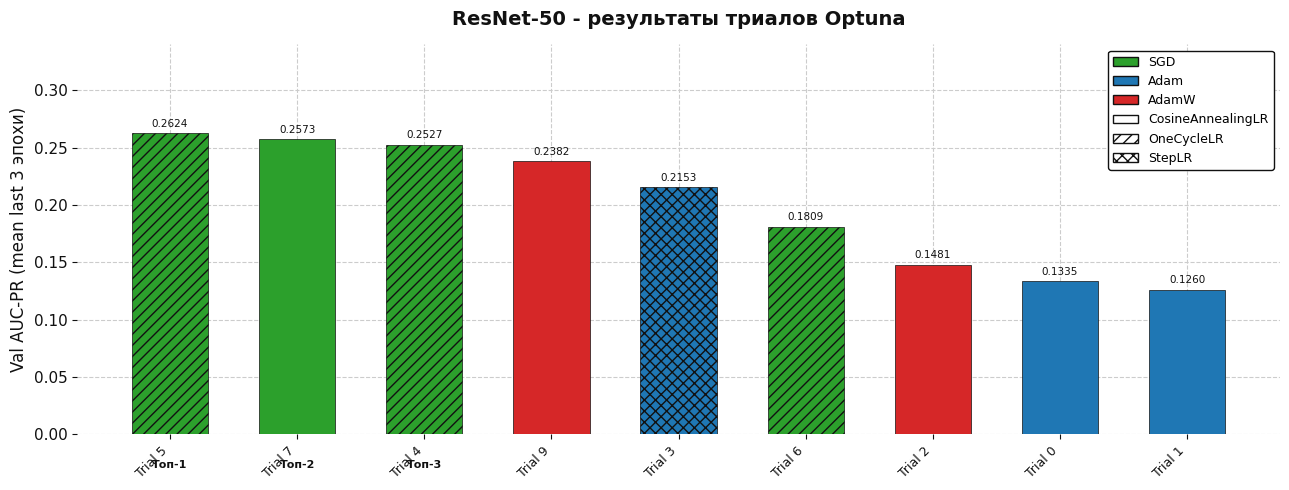

In [4]:
# График: результаты триалов Optuna, ResNet-50

import numpy as np
from matplotlib.patches import Patch

trial_ids  = [5, 7, 4, 9, 3, 6, 2, 0, 1]
aucpr      = [0.2624, 0.2573, 0.2527, 0.2382, 0.2153, 0.1809, 0.1481, 0.1335, 0.1260]
optimizers = ['SGD', 'SGD', 'SGD', 'AdamW', 'Adam', 'SGD', 'AdamW', 'Adam', 'Adam']
schedulers = ['OneCycleLR', 'CosineAnnealingLR', 'OneCycleLR', 'CosineAnnealingLR',
              'StepLR', 'OneCycleLR', 'CosineAnnealingLR', 'CosineAnnealingLR', 'CosineAnnealingLR']

color_map   = {'SGD': C3, 'Adam': C1, 'AdamW': C2}
hatch_map   = {'OneCycleLR': '///', 'CosineAnnealingLR': '', 'StepLR': 'xxx'}
bar_colors  = [color_map[o] for o in optimizers]
hatches     = [hatch_map[s] for s in schedulers]

x = np.arange(len(trial_ids))

fig, ax = plt.subplots(figsize=(13, 5))

for i, (val, color, hatch) in enumerate(zip(aucpr, bar_colors, hatches)):
    ax.bar(i, val, color=color, hatch=hatch, edgecolor='#111111', linewidth=0.5, width=0.6)

for i, val in enumerate(aucpr):
    ax.text(i, val + 0.004, f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, color='#111111')

for i in range(3):
    ax.text(i, -0.022, f'Топ-{i+1}', ha='center', va='top', fontsize=8, color='#111111', fontweight='bold')

legend_elements = [
    Patch(facecolor=C3, edgecolor='#111111', label='SGD'),
    Patch(facecolor=C1, edgecolor='#111111', label='Adam'),
    Patch(facecolor=C2, edgecolor='#111111', label='AdamW'),
    Patch(facecolor='white', edgecolor='#111111', hatch='',    label='CosineAnnealingLR'),
    Patch(facecolor='white', edgecolor='#111111', hatch='///', label='OneCycleLR'),
    Patch(facecolor='white', edgecolor='#111111', hatch='xxx', label='StepLR'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'Trial {t}' for t in trial_ids], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Val AUC-PR (mean last 3 эпохи)')
ax.set_title('ResNet-50 - результаты триалов Optuna')
ax.set_ylim(0, 0.34)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('resnet_optuna_trials.png')
plt.show()

### ResNet-50: подбор гиперпараметров через Optuna

**Топ-3 конфига по val AUC-PR:**
- Триал 5: AUC-PR = 0.2624, SGD + OneCycleLR, lr = 6.2e-5, wd = 8.36e-3, dropout = 0.496, label_smooth = 0.026
- Триал 7: AUC-PR = 0.2573, SGD + CosineAnnealingLR, lr = 1.05e-3, wd = 1.95e-4, dropout = 0.147, label_smooth = 0.142
- Триал 4: AUC-PR = 0.2527, SGD + OneCycleLR, lr = 1.5e-4, wd = 3.9e-4, dropout = 0.375, label_smooth = 0.056

**Наблюдения:**
- SGD с momentum занял все три первых места. Это закономерно: ResNet-50 изначально обучался именно с SGD, и его архитектура (batch normalization, остаточные связи) хорошо согласована с этим оптимизатором. При дообучении pretrained сети SGD аккуратнее обновляет уже хорошо настроенные веса
- Adam и AdamW вне топа - адаптивные оптимизаторы при высоком lr (> 2e-4) слишком агрессивно обновляют pretrained веса и ломают уже выученные признаки
- Лучший lr у топ-3 очень маленький (6.2e-5 - 1.5e-4) - типичный диапазон для аккуратного дообучения

**Вывод:** беру топ-3 триала на расширенное обучение.

---
## 5. Топ-3 конфигурации оптуны на 20 эпох

Беру 3 лучших завершённых (не обрезанных) trial из Optuna. Каждый обучаю на `NUM_EPOCHS_BLOCK2=20` эпох с нуля. После каждой модели сохраняю `.pth` (веса + optimizer + scheduler) и `.json` с метриками. Все метрики выводятся на каждой эпохе.  
**Итоговая метрика модели:** среднее val AUC-PR за последние 3 эпохи.  

In [28]:
# Выбираю топ-K завершённых trials
completed_trials = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True,
)

if len(completed_trials) == 0:
    raise RuntimeError('Нет завершённых trials.')

top_k_trials = completed_trials[:TOP_K]
print('Топ-{} конфигураций для обучения:'.format(TOP_K))
for rank, t in enumerate(top_k_trials):
    print('  Rank {}: Trial #{} | optuna_val_auc_pr={:.4f}'.format(rank + 1, t.number, t.value))

# Загружаю уже сохранённые результаты (защита от перезапуска)
block2_json_path = os.path.join(OUTPUT_DIR, 'block2_results.json')

if os.path.exists(block2_json_path):
    with open(block2_json_path, 'r', encoding='utf-8') as f:
        block2_results = json.load(f)
    print('\nЗагружены результаты предыдущего запуска: {} моделей'.format(len(block2_results)))
else:
    block2_results = []

Топ-3 конфигураций для обучения:
  Rank 1: Trial #5 | optuna_val_auc_pr=0.2624
  Rank 2: Trial #7 | optuna_val_auc_pr=0.2573
  Rank 3: Trial #4 | optuna_val_auc_pr=0.2527


In [33]:
scaler = torch.cuda.amp.GradScaler()

# Обучаю каждую из топ-3 моделей
for rank, trial in enumerate(top_k_trials):
    trial_key  = 'trial_{}'.format(trial.number)
    rank_label = rank + 1  # 1, 2, 3

    # Проверяю, обучена ли уже эта модель в предыдущем запуске
    if any(r.get('trial_key') == trial_key for r in block2_results):
        print('\nRank {} (Trial #{}): уже обучена - пропускаю.'.format(
            rank_label, trial.number))
        continue

    params = trial.params
    print('\n' + '='*70)
    print('RANK {} | Trial #{} | Optuna val_auc_pr={:.4f}'.format(
        rank_label, trial.number, trial.value))
    print('Параметры: {}'.format(params))
    print('='*70)

    # Создаю модель, оптимизатор, планировщик, функцию потерь
    model     = make_resnet50(dropout=params['dropout']).to(DEVICE)
    optimizer = make_optimizer(params, model)
    scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK2, len(train_loader))
    criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

    epoch_history      = []   # полная история всех метрик по эпохам
    val_auc_pr_history = []   # только AUC-PR для скользящего среднего

    for epoch in range(NUM_EPOCHS_BLOCK2):
        epoch_num = epoch + 1

        # Обучаю одну эпоху
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)

        # Все метрики на val (порог подбирается отдельно на каждой эпохе по F1)
        val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
        val_auc_pr_history.append(val_metrics['auc_pr'])

        # Скользящее среднее за последние 3 эпохи
        if epoch >= 2:
            sliding3     = float(np.mean(val_auc_pr_history[-3:]))
            sliding3_str = ' | sliding3={:.4f}'.format(sliding3)
        else:
            sliding3     = None
            sliding3_str = ''

        epoch_history.append({
            'epoch':            epoch_num,
            'train_loss':       round(train_loss, 6),
            'val_loss':         round(val_metrics['loss'], 6),
            'val_auc_pr':       round(val_metrics['auc_pr'], 6),
            'val_f1':           round(val_metrics['f1'], 6),
            'val_recall':       round(val_metrics['recall'], 6),
            'val_precision':    round(val_metrics['precision'], 6),
            'val_specificity':  round(val_metrics['specificity'], 6),
            'val_balanced_acc': round(val_metrics['balanced_accuracy'], 6),
            'val_threshold':    round(val_metrics['threshold'], 4),
            'sliding_mean_3':   round(sliding3, 6) if sliding3 is not None else None,
        })

        # Вывод прогресса - все метрики на каждой эпохе
        print(
            'Ep {:2d}/{} | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
            'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
            'thr={:.2f}{}'.format(
                epoch_num, NUM_EPOCHS_BLOCK2,
                train_loss,
                val_metrics['loss'],
                val_metrics['auc_pr'],
                val_metrics['f1'],
                val_metrics['recall'],
                val_metrics['precision'],
                val_metrics['specificity'],
                val_metrics['balanced_accuracy'],
                val_metrics['threshold'],
                sliding3_str,
            )
        )

    # Ищу лучший порог на val - он будет применён к test
    final_val_metrics  = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
    final_test_metrics = compute_metrics(model, test_loader, criterion=criterion,
                                     threshold=final_val_metrics['threshold'])

    mean_last3 = float(np.mean(val_auc_pr_history[-3:]))

    print('\nФинальные метрики (порог найден на val, применён к test):')
    print('  Val  | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | thr={:.2f}'.format(
        final_val_metrics['auc_pr'], final_val_metrics['f1'],
        final_val_metrics['recall'], final_val_metrics['precision'],
        final_val_metrics['specificity'], final_val_metrics['balanced_accuracy'],
        final_val_metrics['threshold']))
    print('  Test | AUC-PR={:.4f} | F1={:.4f} | Rec={:.4f} | '
          'Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f}'.format(
        final_test_metrics['auc_pr'], final_test_metrics['f1'],
        final_test_metrics['recall'], final_test_metrics['precision'],
        final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))
    print('  Итоговая метрика (mean last-3 val AUC-PR): {:.4f}'.format(mean_last3))

    # Сохраняю чекпоинт
    ckpt_filename = 'block2_rank{}_trial{}.pth'.format(rank_label, trial.number)
    ckpt_path     = os.path.join(OUTPUT_DIR, ckpt_filename)
    torch.save({
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'params':               params,
        'val_auc_pr_history':   val_auc_pr_history,
        'epoch':                NUM_EPOCHS_BLOCK2,
        'trial_number':         trial.number,
        'rank':                 rank_label,
    }, ckpt_path)
    print('Веса сохранены:', ckpt_path)
    ipd.display(ipd.FileLink(ckpt_path))

    # Записываю результат в список
    def round_metrics(d):
        return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

    block2_results.append({
        'trial_key':             trial_key,
        'rank':                  rank_label,
        'trial_number':          trial.number,
        'optuna_value':          round(trial.value, 6),
        'params':                params,
        'epoch_history':         epoch_history,
        'mean_last3_val_auc_pr': round(mean_last3, 6),
        'final_val_metrics':     round_metrics(final_val_metrics),
        'final_test_metrics':    round_metrics(final_test_metrics),
        'checkpoint_path':       ckpt_path,
    })

    # Сохраняю JSON сразу после каждой модели
    save_results(block2_results, block2_json_path)

    # Освобождаю GPU-память
    del model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()


RANK 1 | Trial #5 | Optuna val_auc_pr=0.2624
Параметры: {'optimizer': 'SGD', 'scheduler': 'OneCycleLR', 'lr': 6.206884258778405e-05, 'weight_decay': 0.008356023455852362, 'dropout': 0.4956967045790668, 'label_smoothing': 0.025998501848389168}
Ep  1/30 | train_loss=0.7053 | val_loss=0.6987 | AUC-PR=0.0381 | F1=0.0873 | Rec=0.1644 | Prec=0.0594 | Spec=0.9533 | BalAcc=0.5588 | thr=0.59
Ep  2/30 | train_loss=0.6469 | val_loss=0.6162 | AUC-PR=0.0806 | F1=0.1410 | Rec=0.2192 | Prec=0.1039 | Spec=0.9661 | BalAcc=0.5926 | thr=0.64
Ep  3/30 | train_loss=0.5714 | val_loss=0.5457 | AUC-PR=0.0987 | F1=0.1415 | Rec=0.3014 | Prec=0.0924 | Spec=0.9469 | BalAcc=0.6241 | thr=0.70 | sliding3=0.0725
Ep  4/30 | train_loss=0.5068 | val_loss=0.4473 | AUC-PR=0.1395 | F1=0.1618 | Rec=0.1507 | Prec=0.1746 | Spec=0.9872 | BalAcc=0.5690 | thr=0.82 | sliding3=0.1063
Ep  5/30 | train_loss=0.4703 | val_loss=0.4525 | AUC-PR=0.1566 | F1=0.1980 | Rec=0.1370 | Prec=0.3571 | Spec=0.9956 | BalAcc=0.5663 | thr=0.91 | sli

/kaggle/working/block2_rank1_trial5.pth

Сохранено: /kaggle/working/block2_results.json


/kaggle/working/block2_results.json


RANK 2 | Trial #7 | Optuna val_auc_pr=0.2573
Параметры: {'optimizer': 'SGD', 'scheduler': 'CosineAnnealingLR', 'lr': 0.001053822936754517, 'weight_decay': 0.0001950011961529106, 'dropout': 0.14749160873584166, 'label_smoothing': 0.14176597156668097}
Ep  1/30 | train_loss=0.4588 | val_loss=0.3858 | AUC-PR=0.1877 | F1=0.2788 | Rec=0.3973 | Prec=0.2148 | Spec=0.9739 | BalAcc=0.6856 | thr=0.73
Ep  2/30 | train_loss=0.3575 | val_loss=0.3562 | AUC-PR=0.2592 | F1=0.3066 | Rec=0.2877 | Prec=0.3281 | Spec=0.9894 | BalAcc=0.6386 | thr=0.84
Ep  3/30 | train_loss=0.3220 | val_loss=0.3193 | AUC-PR=0.2809 | F1=0.3186 | Rec=0.2466 | Prec=0.4500 | Spec=0.9946 | BalAcc=0.6206 | thr=0.80 | sliding3=0.2426
Ep  4/30 | train_loss=0.3064 | val_loss=0.3165 | AUC-PR=0.2624 | F1=0.3175 | Rec=0.2740 | Prec=0.3774 | Spec=0.9919 | BalAcc=0.6329 | thr=0.74 | sliding3=0.2675
Ep  5/30 | train_loss=0.2962 | val_loss=0.3101 | AUC-PR=0.2456 | F1=0.3259 | Rec=0.3014 | Prec=0.3548 | Spec=0.9902 | BalAcc=0.6458 | thr=0.6

...

/kaggle/working/block2_results.json


RANK 3 | Trial #4 | Optuna val_auc_pr=0.2527
Параметры: {'optimizer': 'SGD', 'scheduler': 'OneCycleLR', 'lr': 0.00015042289850713422, 'weight_decay': 0.0003902246764605478, 'dropout': 0.37451925988590584, 'label_smoothing': 0.05591823759326926}
Ep  1/30 | train_loss=0.6637 | val_loss=0.6259 | AUC-PR=0.1070 | F1=0.1895 | Rec=0.2466 | Prec=0.1538 | Spec=0.9757 | BalAcc=0.6111 | thr=0.64
Ep  2/30 | train_loss=0.5602 | val_loss=0.5266 | AUC-PR=0.1118 | F1=0.1806 | Rec=0.1781 | Prec=0.1831 | Spec=0.9857 | BalAcc=0.5819 | thr=0.79
Ep  3/30 | train_loss=0.4918 | val_loss=0.4749 | AUC-PR=0.1816 | F1=0.2261 | Rec=0.1781 | Prec=0.3095 | Spec=0.9929 | BalAcc=0.5855 | thr=0.88 | sliding3=0.1335
Ep  4/30 | train_loss=0.4584 | val_loss=0.4215 | AUC-PR=0.2034 | F1=0.2609 | Rec=0.2466 | Prec=0.2769 | Spec=0.9884 | BalAcc=0.6175 | thr=0.87 | sliding3=0.1656
Ep  5/30 | train_loss=0.4249 | val_loss=0.4467 | AUC-PR=0.2252 | F1=0.3053 | Rec=0.2740 | Prec=0.3448 | Spec=0.9907 | BalAcc=0.6323 | thr=0.91 | s

/kaggle/working/block2_rank3_trial4.pth

Сохранено: /kaggle/working/block2_results.json


/kaggle/working/block2_results.json

In [34]:
# Итоговая таблица сравнения трёх моделей
print('\n' + '='*80)
print('ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ')
print('='*80)

header = '{:<5} {:<10} {:<20} {:<12} {:<12} {:<12} {:<10}'.format(
    'Rank', 'Trial#', 'mean_last3_AUC-PR', 'Val AUC-PR', 'Test AUC-PR',
    'Test Recall', 'Test F1'
)
print(header)
print('-'*80)

for r in sorted(block2_results, key=lambda x: x['mean_last3_val_auc_pr'], reverse=True):
    print('{:<5} {:<10} {:<20.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<10.4f}'.format(
        r['rank'],
        r['trial_number'],
        r['mean_last3_val_auc_pr'],
        r['final_val_metrics']['auc_pr'],
        r['final_test_metrics']['auc_pr'],
        r['final_test_metrics']['recall'],
        r['final_test_metrics']['f1'],
    ))

best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('\nЛучший по mean_last3_val_auc_pr:')
print('  Rank={} | Trial={} | mean_last3={:.4f} | Параметры: {}'.format(
    best_b2['rank'], best_b2['trial_number'],
    best_b2['mean_last3_val_auc_pr'], best_b2['params']))


ИТОГИ ЧАСТИ 5: СРАВНЕНИЕ ТОП-3 КОНФИГУРАЦИЙ
Rank  Trial#     mean_last3_AUC-PR    Val AUC-PR   Test AUC-PR  Test Recall  Test F1   
--------------------------------------------------------------------------------
3     4          0.2532               0.2454       0.1988       0.3425       0.3205    
2     7          0.2228               0.2222       0.2457       0.3836       0.3415    
1     5          0.2098               0.2098       0.2152       0.2877       0.2625    

Лучший по mean_last3_val_auc_pr:
  Rank=3 | Trial=4 | mean_last3=0.2532 | Параметры: {'optimizer': 'SGD', 'scheduler': 'OneCycleLR', 'lr': 0.00015042289850713422, 'weight_decay': 0.0003902246764605478, 'dropout': 0.37451925988590584, 'label_smoothing': 0.05591823759326926}


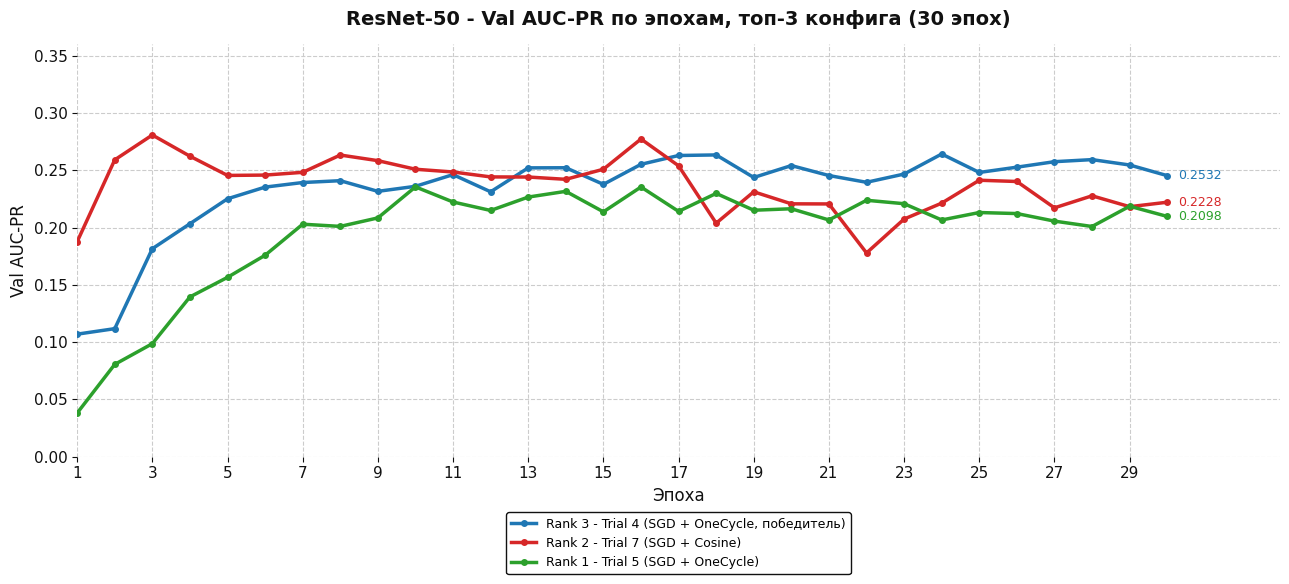

In [5]:
# График 1: val AUC-PR по эпохам, топ-3 конфига ResNet-50

epochs = list(range(1, 31))

val_rank1 = [0.0381, 0.0806, 0.0987, 0.1395, 0.1566, 0.1759, 0.2030, 0.2011, 0.2085, 0.2356,
             0.2224, 0.2150, 0.2267, 0.2317, 0.2138, 0.2355, 0.2142, 0.2299, 0.2152, 0.2165,
             0.2067, 0.2239, 0.2209, 0.2067, 0.2132, 0.2123, 0.2057, 0.2010, 0.2187, 0.2098]

val_rank2 = [0.1877, 0.2592, 0.2809, 0.2624, 0.2456, 0.2459, 0.2483, 0.2634, 0.2585, 0.2510,
             0.2486, 0.2443, 0.2442, 0.2422, 0.2510, 0.2774, 0.2540, 0.2039, 0.2313, 0.2208,
             0.2207, 0.1779, 0.2075, 0.2214, 0.2414, 0.2403, 0.2173, 0.2278, 0.2183, 0.2222]

val_rank3 = [0.1070, 0.1118, 0.1816, 0.2034, 0.2252, 0.2354, 0.2394, 0.2410, 0.2317, 0.2361,
             0.2463, 0.2313, 0.2522, 0.2523, 0.2378, 0.2553, 0.2630, 0.2635, 0.2438, 0.2542,
             0.2455, 0.2396, 0.2468, 0.2643, 0.2482, 0.2528, 0.2576, 0.2594, 0.2547, 0.2454]

fig, ax = plt.subplots(figsize=(13, 6))

for vals, color, label, mean_last3 in [
    (val_rank3, C1, 'Rank 3 - Trial 4 (SGD + OneCycle, победитель)', '0.2532'),
    (val_rank2, C2, 'Rank 2 - Trial 7 (SGD + Cosine)',               '0.2228'),
    (val_rank1, C3, 'Rank 1 - Trial 5 (SGD + OneCycle)',             '0.2098'),
]:
    ax.plot(epochs, vals, color=color, marker='o', markersize=4, label=label)
    ax.annotate(mean_last3, xy=(30, vals[-1]), xytext=(30.3, vals[-1]),
                fontsize=9, color=color, va='center')

ax.set_xlabel('Эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('ResNet-50 - Val AUC-PR по эпохам, топ-3 конфига (30 эпох)')
ax.set_xticks(list(range(1, 31, 2)))
ax.set_xlim(1, 33)
ax.set_ylim(0, 0.36)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=1)
plt.tight_layout()
plt.savefig('resnet_top3_val_aucpr.png')
plt.show()

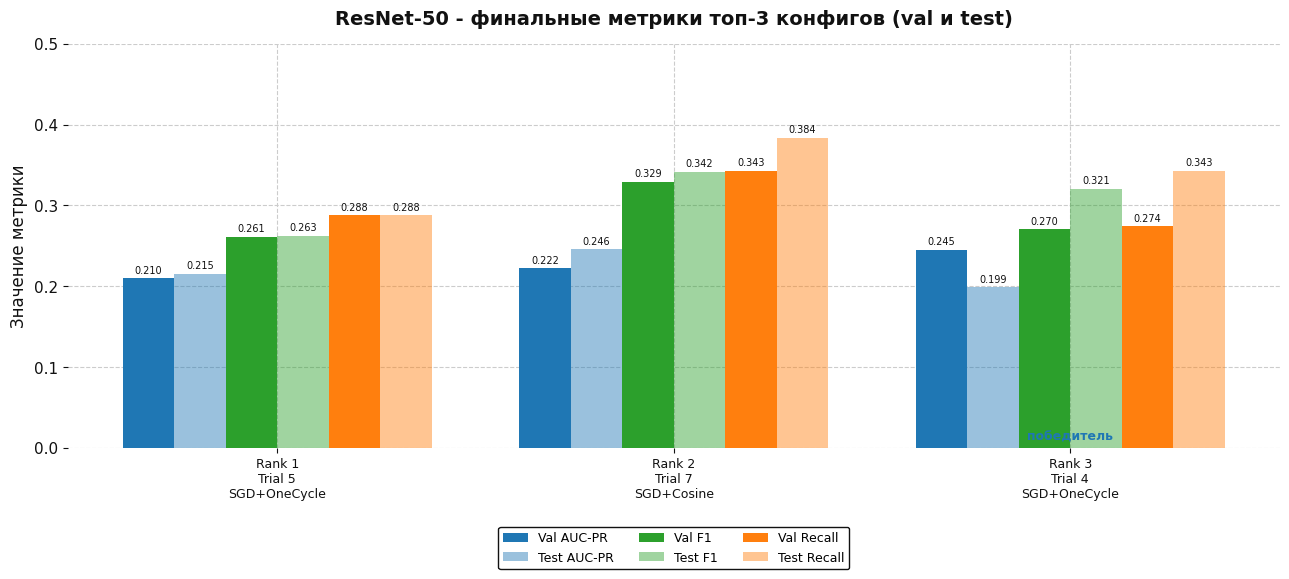

In [7]:
# График 2: столбчатый - val и test AUC-PR, F1, Recall для топ-3 ResNet-50

configs = ['Rank 1\nTrial 5\nSGD+OneCycle', 'Rank 2\nTrial 7\nSGD+Cosine', 'Rank 3\nTrial 4\nSGD+OneCycle']

val_aucpr  = [0.2098, 0.2222, 0.2454]
test_aucpr = [0.2152, 0.2457, 0.1988]
val_f1     = [0.2609, 0.3289, 0.2703]
test_f1    = [0.2625, 0.3415, 0.3205]
val_rec    = [0.2877, 0.3425, 0.2740]
test_rec   = [0.2877, 0.3836, 0.3425]

x     = np.arange(len(configs))
width = 0.13

fig, ax = plt.subplots(figsize=(13, 6))

bars = [
    ax.bar(x - 2.5*width, val_aucpr,  width, label='Val AUC-PR',  color=C1),
    ax.bar(x - 1.5*width, test_aucpr, width, label='Test AUC-PR', color=C1, alpha=0.45),
    ax.bar(x - 0.5*width, val_f1,     width, label='Val F1',      color=C3),
    ax.bar(x + 0.5*width, test_f1,    width, label='Test F1',     color=C3, alpha=0.45),
    ax.bar(x + 1.5*width, val_rec,    width, label='Val Recall',  color=C4),
    ax.bar(x + 2.5*width, test_rec,   width, label='Test Recall', color=C4, alpha=0.45),
]

for bar_group in bars:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, color='#111111')

ax.text(2, 0.01, 'победитель', ha='center', fontsize=9, color=C1, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('Значение метрики')
ax.set_title('ResNet-50 - финальные метрики топ-3 конфигов (val и test)')
ax.set_ylim(0, 0.50)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=True, fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig('resnet_top3_metrics_bar.png')
plt.show()

### ResNet-50: расширенное обучение топ-3 конфигов (30 эпох)

**Результаты:**
- Rank 1 (Trial 5, SGD + OneCycle, lr=6.2e-5): mean last3 = 0.2098 - медленный старт (первые 3 эпохи AUC-PR ниже 0.10), затем стабильный рост до эпохи 16, после чего plateau
- Rank 2 (Trial 7, SGD + Cosine, lr=1.05e-3): mean last3 = 0.2228 - быстрый старт, пик на эпохе 3 (0.2809), затем стабильное плато в диапазоне 0.22-0.26 до конца
- Rank 3 (Trial 4, SGD + OneCycle, lr=1.5e-4): mean last3 = 0.2532 - победитель несмотря на третье место в Optuna. Стабильный рост до эпохи 18, затем устойчивое плато

**Победитель: Rank 3, Trial 4** - mean last3 val AUC-PR = 0.2532, наилучшая итоговая метрика на длинном горизонте.

**Наблюдение:** ранжирование Optuna (10 эпох) не совпало с результатами на 30 эпохах - Rank 3 обогнал Rank 1 и Rank 2. Это типичная ситуация: короткие триалы не всегда предсказывают поведение модели на длинном обучении.

---
## 6. Дообучение лучшей модели

Беру лучшую из топ-3 по **среднему val AUC-PR за последние 3 эпохи** из прошлой части. Загружаю её веса, optimizer и scheduler из чекпоинта части 5.  

**Критерий сохранения лучших весов:** максимальное скользящее среднее val AUC-PR за последние 3 эпохи из общей истории.  

**Early stopping:** patience=7 эпох без улучшения скользящего среднего. Счётчик ведётся от лучшего значения за **всё время** (включая предыдщую часть).  

**Первые 2 эпохи части 6 (глобально 21–22):** не сохраняю и не считаю patience. С 23-ей эпохи скользящее окно `[-3:]` заполнено только новыми эпохами.   

**Итоговая метрика для отчёта:** среднее val AUC-PR за последние 3 эпохи.

In [27]:
block2_json_path = '/kaggle/input/datasets/dashkanikitina/block2-results-resnet/block2_results.json'

with open(block2_json_path, 'r', encoding='utf-8') as f:
    block2_results = json.load(f)

print('Загружено результатов:', len(block2_results))

PTH_DIR = '/kaggle/input/models/dashkanikitina/resnet-top3/pytorch/default/1'

for r in block2_results:
    r['checkpoint_path'] = os.path.join(PTH_DIR, os.path.basename(r['checkpoint_path']))

Загружено результатов: 3


In [28]:
# Выбираю лучшую модель из топ-3 по среднему AUC-PR
best_b2 = max(block2_results, key=lambda r: r['mean_last3_val_auc_pr'])
print('Лучшая модель из части 5:')
print('  Rank={} | Trial={} | mean_last3_val_auc_pr={:.4f}'.format(
    best_b2['rank'], best_b2['trial_number'], best_b2['mean_last3_val_auc_pr']))
print('  Параметры: {}'.format(best_b2['params']))
print('  Загружаю из: {}'.format(best_b2['checkpoint_path']))

checkpoint = torch.load(best_b2['checkpoint_path'], map_location=DEVICE)
params     = checkpoint['params']

model = make_resnet50(dropout=params['dropout']).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

optimizer = make_optimizer(params, model)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
for state in optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.to(DEVICE)

scheduler = make_scheduler(params, optimizer, NUM_EPOCHS_BLOCK3, len(train_loader))
if params['scheduler'] == 'OneCycleLR':
    print('Scheduler OneCycleLR: начинаю новый цикл на {} эпох (продолжить старый нельзя).'.format(NUM_EPOCHS_BLOCK3))
else:
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    print('Scheduler {} загружен из checkpoint, продолжаю с того места, где остановились.'.format(params['scheduler']))

criterion = LabelSmoothingBCELoss(label_smoothing=params['label_smoothing'])

val_auc_pr_history = checkpoint['val_auc_pr_history']
print('Загружена история части 5, ({} эпох).'.format(len(val_auc_pr_history)))

# NEW: путь для посэпохового чекпоинта части 6
block3_ckpt_path = os.path.join(OUTPUT_DIR, 'block3_checkpoint.pth')

# NEW: если уже есть сохранённый прогресс части 6 (например, после обрыва сессии) - продолжаю с него
if os.path.exists(block3_ckpt_path):
    b3_ckpt = torch.load(block3_ckpt_path, map_location=DEVICE)
    model.load_state_dict(b3_ckpt['model_state_dict'])
    optimizer.load_state_dict(b3_ckpt['optimizer_state_dict'])
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(DEVICE)
    scheduler.load_state_dict(b3_ckpt['scheduler_state_dict'])
    val_auc_pr_history   = b3_ckpt['val_auc_pr_history']
    block3_epoch_history = b3_ckpt['block3_epoch_history']
    best_sliding_mean    = b3_ckpt['best_sliding_mean']
    best_weights         = b3_ckpt['best_weights']
    best_epoch_global    = b3_ckpt['best_epoch_global']
    patience_counter     = b3_ckpt['patience_counter']
    start_epoch          = b3_ckpt['next_epoch']
    print('Найден прогресс части 6 - продолжаю с локальной эпохи {}.'.format(start_epoch + 1))
else:
    best_sliding_mean    = float(np.mean(val_auc_pr_history[-3:]))
    best_weights         = copy.deepcopy(model.state_dict())
    patience_counter     = 0
    best_epoch_global    = NUM_EPOCHS_BLOCK2
    block3_epoch_history = []
    start_epoch          = 0
    print('Начинаю часть 6 с нуля.')

print('Начальное лучшее скользящее среднее: {:.4f}'.format(best_sliding_mean))
print('Дообучаю до {} эпох с early stopping (patience={}).\n'.format(
    NUM_EPOCHS_BLOCK3, EARLY_STOPPING_PATIENCE))

early_stopped = False
scaler = torch.cuda.amp.GradScaler()

for epoch in range(start_epoch, NUM_EPOCHS_BLOCK3):   # CHANGED: range(start_epoch, ...) вместо range(NUM_EPOCHS_BLOCK3)
    epoch_local  = epoch + 1
    epoch_global = NUM_EPOCHS_BLOCK2 + epoch + 1

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler=scaler)
    val_metrics = compute_metrics(model, val_loader, criterion=criterion, threshold=None)
    val_auc_pr_history.append(val_metrics['auc_pr'])

    sliding_mean = float(np.mean(val_auc_pr_history[-3:]))

    star = ''
    if epoch >= 2 and sliding_mean > best_sliding_mean:
        star = ' BEST'

    print(
        'Ep {:2d}/{} (glob {:2d}) | train_loss={:.4f} | val_loss={:.4f} | AUC-PR={:.4f} | F1={:.4f} | '
        'Rec={:.4f} | Prec={:.4f} | Spec={:.4f} | BalAcc={:.4f} | '
        'thr={:.2f} | AVG_3 AUC-PR={:.4f}{}'.format(
            epoch_local, NUM_EPOCHS_BLOCK3, epoch_global,
            train_loss, val_metrics['loss'], val_metrics['auc_pr'], val_metrics['f1'],
            val_metrics['recall'], val_metrics['precision'], val_metrics['specificity'],
            val_metrics['balanced_accuracy'], val_metrics['threshold'], sliding_mean, star,
        )
    )

    block3_epoch_history.append({
        'epoch_local': epoch_local, 'epoch_global': epoch_global,
        'train_loss': round(train_loss, 6), 'val_loss': round(val_metrics['loss'], 6),
        'val_auc_pr': round(val_metrics['auc_pr'], 6), 'val_f1': round(val_metrics['f1'], 6),
        'val_recall': round(val_metrics['recall'], 6), 'val_precision': round(val_metrics['precision'], 6),
        'val_specificity': round(val_metrics['specificity'], 6),
        'val_balanced_acc': round(val_metrics['balanced_accuracy'], 6),
        'val_threshold': round(val_metrics['threshold'], 4), 'sliding_mean_3': round(sliding_mean, 6),
    })

    if epoch >= 2:
        if sliding_mean > best_sliding_mean:
            best_sliding_mean  = sliding_mean
            best_weights       = copy.deepcopy(model.state_dict())
            best_epoch_global  = epoch_global
            patience_counter   = 0
        else:
            patience_counter += 1

    # NEW: сохраняю прогресс на диск после каждой эпохи
    torch.save({
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_auc_pr_history':   val_auc_pr_history,
        'block3_epoch_history': block3_epoch_history,
        'best_sliding_mean':    best_sliding_mean,
        'best_weights':         best_weights,
        'best_epoch_global':    best_epoch_global,
        'patience_counter':     patience_counter,
        'next_epoch':           epoch + 1,
    }, block3_ckpt_path)

    if epoch >= 2 and patience_counter >= EARLY_STOPPING_PATIENCE:
        print('\nEarly stopping: {} эпох без улучшения.'.format(EARLY_STOPPING_PATIENCE))
        print('Лучшие веса: глобальная эпоха {}.'.format(best_epoch_global))
        early_stopped = True
        break

model.load_state_dict(best_weights)
print('\nЗагружены лучшие веса (глобальная эпоха {}).'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))

Лучшая модель из части 5:
  Rank=3 | Trial=4 | mean_last3_val_auc_pr=0.2532
  Параметры: {'optimizer': 'SGD', 'scheduler': 'OneCycleLR', 'lr': 0.00015042289850713422, 'weight_decay': 0.0003902246764605478, 'dropout': 0.37451925988590584, 'label_smoothing': 0.05591823759326926}
  Загружаю из: /kaggle/input/models/dashkanikitina/resnet-top3/pytorch/default/1/block2_rank3_trial4.pth
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


Scheduler OneCycleLR: начинаю новый цикл на 20 эпох (продолжить старый нельзя).
Загружена история части 5, (30 эпох).
Начинаю часть 6 с нуля.
Начальное лучшее скользящее среднее: 0.2532
Дообучаю до 20 эпох с early stopping (patience=7).

Ep  1/20 (glob 31) | train_loss=0.1727 | val_loss=0.2068 | AUC-PR=0.2487 | F1=0.2801 | Rec=0.5890 | Prec=0.1838 | Spec=0.9530 | BalAcc=0.7710 | thr=0.24 | AVG_3 AUC-PR=0.2496
Ep  2/20 (glob 32) | train_loss=0.1733 | val_loss=0.2098 | AUC-PR=0.2547 | F1=0.2913 | Rec=0.4110 | Prec=0.2256 | Spec=0.9747 | BalAcc=0.6928 | thr=0.47 | AVG_3 AUC-PR=0.2496
Ep  3/20 (glob 33) | train_loss=0.1739 | val_loss=0.2011 | AUC-PR=0.2425 | F1=0.2700 | Rec=0.4384 | Prec=0.1951 | Spec=0.9676 | BalAcc=0.7030 | thr=0.30 | AVG_3 AUC-PR=0.2486
Ep  4/20 (glob 34) | train_loss=0.1741 | val_loss=0.1999 | AUC-PR=0.2590 | F1=0.3106 | Rec=0.3425 | Prec=0.2841 | Spec=0.9845 | BalAcc=0.6635 | thr=0.55 | AVG_3 AUC-PR=0.2520
Ep  5/20 (glob 35) | train_loss=0.1694 | val_loss=0.1971 | AUC

In [29]:
# Финальные метрики и сохранение результатов

# Порог подбираю на val с лучшими весами, применяем на test
final_val_metrics  = compute_metrics(model, val_loader,  criterion=criterion, threshold=None)
final_test_metrics = compute_metrics(model, test_loader, criterion=criterion,
                                     threshold=final_val_metrics['threshold'])

# Итоговая метрика для отчёта: среднее AUC-PR за последние 3 эпохи
last3_auc_pr      = [r['val_auc_pr'] for r in block3_epoch_history[-3:]]
mean_last3_block3 = float(np.mean(last3_auc_pr))

print('\n' + '='*70)
print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6')
print('='*70)
print('Эпох дообучения: {} из {} | Early stopping: {}'.format(
    len(block3_epoch_history), NUM_EPOCHS_BLOCK3, early_stopped))
print('Лучшие веса: глобальная эпоха {}'.format(best_epoch_global))
print('Лучшее скользящее среднее val AUC-PR: {:.4f}'.format(best_sliding_mean))
print('Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): {:.4f}'.format(mean_last3_block3))

print('\nVal-метрики (порог={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_val_metrics['auc_pr'],  final_val_metrics['f1'],
    final_val_metrics['recall'],  final_val_metrics['precision'],
    final_val_metrics['specificity'], final_val_metrics['balanced_accuracy']))

print('\nTest-метрики (порог с val={:.2f}):'.format(final_val_metrics['threshold']))
print('  AUC-PR={:.4f} | F1={:.4f} | Recall={:.4f} | Precision={:.4f} | '
      'Specificity={:.4f} | BalAcc={:.4f}'.format(
    final_test_metrics['auc_pr'],  final_test_metrics['f1'],
    final_test_metrics['recall'],  final_test_metrics['precision'],
    final_test_metrics['specificity'], final_test_metrics['balanced_accuracy']))

# Сохраняю веса финальной модели
final_model_path = os.path.join(OUTPUT_DIR, 'block3_final_model.pth')
torch.save({
    'model_state_dict':           best_weights,
    'params':                     params,
    'best_epoch_global':          best_epoch_global,
    'best_sliding_mean':          best_sliding_mean,
    'val_auc_pr_history_full':    val_auc_pr_history,
    'early_stopped':              early_stopped,
}, final_model_path)
print('\nВеса финальной модели сохранены:', final_model_path)
ipd.display(ipd.FileLink(final_model_path))

# Сохраняю результаты в JSON
def round_metrics(d):
    return {k: round(v, 6) if isinstance(v, float) else v for k, v in d.items()}

block3_results = [{
    'source_trial_number':          best_b2['trial_number'],
    'source_rank':                  best_b2['rank'],
    'params':                       params,
    'epochs_run_block3':            len(block3_epoch_history),
    'early_stopped':                early_stopped,
    'best_epoch_global':            best_epoch_global,
    'best_sliding_mean_val_auc_pr': round(best_sliding_mean, 6),
    'mean_last3_val_auc_pr_block3': round(mean_last3_block3, 6),
    'epoch_history_block3':         block3_epoch_history,
    'final_val_metrics':            round_metrics(final_val_metrics),
    'final_test_metrics':           round_metrics(final_test_metrics),
    'model_path':                   final_model_path,
}]

block3_json_path = os.path.join(OUTPUT_DIR, 'block3_results.json')
save_results(block3_results, block3_json_path)

print('\nФинальная модель обучена и сохранена.')


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ЧАСТИ 6
Эпох дообучения: 13 из 20 | Early stopping: True
Лучшие веса: глобальная эпоха 36
Лучшее скользящее среднее val AUC-PR: 0.2608
Итоговая метрика (mean last-3 val AUC-PR ЧАСТИ 6): 0.2532

Val-метрики (порог=0.50):
  AUC-PR=0.2539 | F1=0.2738 | Recall=0.3151 | Precision=0.2421 | Specificity=0.9823 | BalAcc=0.6487

Test-метрики (порог с val=0.50):
  AUC-PR=0.1964 | F1=0.2754 | Recall=0.3151 | Precision=0.2447 | Specificity=0.9825 | BalAcc=0.6488

Веса финальной модели сохранены: /kaggle/working/block3_final_model.pth


/kaggle/working/block3_final_model.pth

Сохранено: /kaggle/working/block3_results.json


/kaggle/working/block3_results.json


Финальная модель обучена и сохранена.


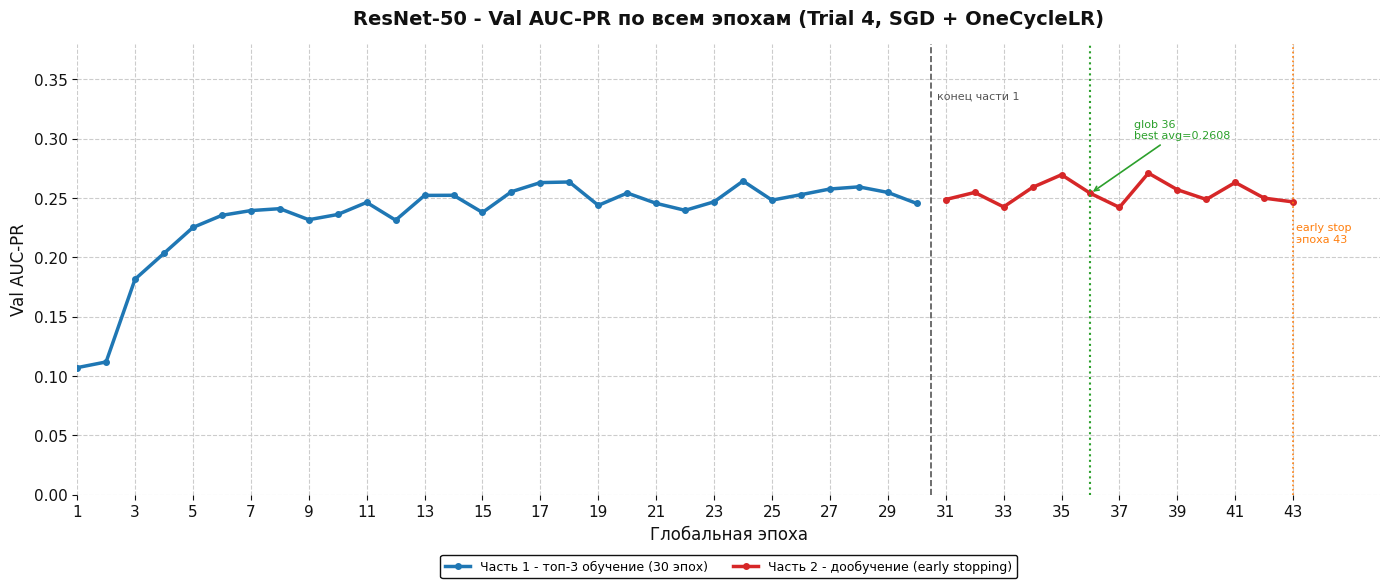

In [8]:
# График 1: сквозной val AUC-PR, ResNet-50 - эпохи 1-43

epochs_p1  = list(range(1, 31))
epochs_p2  = list(range(31, 44))
epochs_all = epochs_p1 + epochs_p2

val_aucpr_p1 = [0.1070, 0.1118, 0.1816, 0.2034, 0.2252, 0.2354, 0.2394, 0.2410, 0.2317, 0.2361,
                0.2463, 0.2313, 0.2522, 0.2523, 0.2378, 0.2553, 0.2630, 0.2635, 0.2438, 0.2542,
                0.2455, 0.2396, 0.2468, 0.2643, 0.2482, 0.2528, 0.2576, 0.2594, 0.2547, 0.2454]

val_aucpr_p2 = [0.2487, 0.2547, 0.2425, 0.2590, 0.2696, 0.2539, 0.2421, 0.2710, 0.2570,
                0.2488, 0.2631, 0.2499, 0.2467]

val_aucpr_all = val_aucpr_p1 + val_aucpr_p2

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(epochs_p1, val_aucpr_p1, color=C1, marker='o', markersize=4, label='Часть 1 - топ-3 обучение (30 эпох)')
ax.plot(epochs_p2, val_aucpr_p2, color=C2, marker='o', markersize=4, label='Часть 2 - дообучение (early stopping)')

# Граница между частями
ax.axvline(30.5, color=C_GRAY, linewidth=1.2, linestyle='--')
ax.text(30.7, 0.34, 'конец части 1', fontsize=8, color=C_GRAY, va='top')

# Лучшая эпоха - glob 36 = локальная эпоха 6 части 2
ax.axvline(36, color=C3, linewidth=1.5, linestyle=':')
ax.annotate('glob 36\nbest avg=0.2608',
            xy=(36, val_aucpr_all[35]), xytext=(37.5, 0.30),
            arrowprops=dict(arrowstyle='->', color=C3, lw=1.2),
            fontsize=8, color=C3)

# Early stopping
ax.axvline(43, color=C4, linewidth=1.2, linestyle=':')
ax.text(43.1, 0.22, 'early stop\nэпоха 43', fontsize=8, color=C4, va='center')

ax.set_xlabel('Глобальная эпоха')
ax.set_ylabel('Val AUC-PR')
ax.set_title('ResNet-50 - Val AUC-PR по всем эпохам (Trial 4, SGD + OneCycleLR)')
ax.set_xticks(list(range(1, 44, 2)))
ax.set_xlim(1, 46)
ax.set_ylim(0, 0.38)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=True, fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('resnet_full_val_aucpr.png')
plt.show()

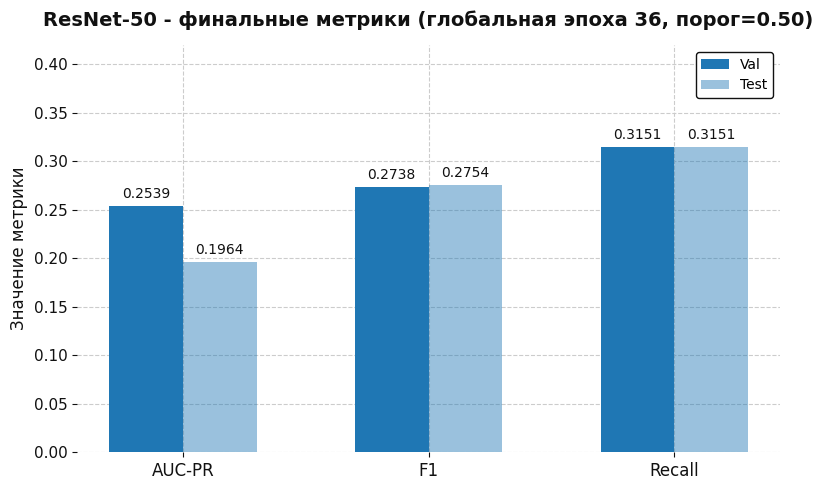

In [9]:
# График 2: столбчатый - val vs test, ResNet-50 финальные метрики

import numpy as np

metrics   = ['AUC-PR', 'F1', 'Recall']
val_vals  = [0.2539, 0.2738, 0.3151]
test_vals = [0.1964, 0.2754, 0.3151]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars_val  = ax.bar(x - width/2, val_vals,  width, label='Val',  color=C1)
bars_test = ax.bar(x + width/2, test_vals, width, label='Test', color=C1, alpha=0.45)

for bars in [bars_val, bars_test]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.4f}', ha='center', va='bottom', fontsize=10, color='#111111')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Значение метрики')
ax.set_title('ResNet-50 - финальные метрики (глобальная эпоха 36, порог=0.50)')
ax.set_ylim(0, 0.42)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('resnet_final_metrics_bar.png')
plt.show()

### ResNet-50: дообучение победителя до 20 эпох

Обучение остановилось на глобальной эпохе 43 - 7 эпох без улучшения скользящего среднего. Лучшие веса зафиксированы на глобальной эпохе 36 (avg=0.2608).

**Финальные метрики (порог=0.50, найден на val):**
- Val: AUC-PR=0.2539, F1=0.2738, Recall=0.3151
- Test: AUC-PR=0.1964, F1=0.2754, Recall=0.3151

Val и test Recall совпадают (0.3151) - порог хорошо перенёсся. Однако test AUC-PR заметно ниже val (0.1964 vs 0.2539) - это говорит о том, что кривая precision-recall на тесте в целом хуже, хотя в конкретной точке порога модель ведёт себя одинаково.